In [1]:
import pandas as pd

In [2]:
OzOFF_database_path="lipid_database/OzOFF_database/Database_OzOFF.parquet"
OzON_database_path = "lipid_database/OzON_databases/OzON_Possible_Database_0.parquet"
df_OFF = pd.read_parquet(OzOFF_database_path)
df_ON = pd.read_parquet(OzON_database_path)
df_OFF

,Lipid,Parent_Ion,Product_Ion,Class,Chain_length
0,FA(d2-16:0),425.4,183,FA,16
1,FA(5:0),269.3,183,FA,5
2,FA(5:1),267.3,183,FA,5
3,FA(5:2),265.3,183,FA,5
4,FA(5:3),263.3,183,FA,5
...,...,...,...,...,...
153,FA(30:1),617.3,183,FA,30
154,FA(30:2),615.3,183,FA,30
155,FA(30:3),613.3,183,FA,30
156,FA(30:4),611.3,183,FA,30


In [3]:
df_ON

,Lipid,Parent_Ion,Product_Ion,Species,Class,DB Location,FA mass,[FA+AMP]+
0,FA(5:0),269.3,183.0,5:0,FA,None,102.2,281.3
1,FA(6:0),283.3,183.0,6:0,FA,None,116.2,295.3
2,FA(6:1)_<>_n-2,269.2,183.0,6:1,FA,<>,114.1,281.2
3,FA(6:1)_<>_n-3,255.2,183.0,6:1,FA,<>,114.1,281.2
4,FA(6:1)_<>_n-4,241.2,183.0,6:1,FA,<>,114.1,281.2
...,...,...,...,...,...,...,...,...
6531,FA(30:6)_<BBFFF>_n-26,265.5,183.0,30:6,FA,<BBFFF>,440.4,607.5
6532,FA(30:6)_<FFFFF>_n-27,255.5,183.0,30:6,FA,<FFFFF>,440.4,607.5
6533,FA(30:6)_<BFFFF>_n-27,253.5,183.0,30:6,FA,<BFFFF>,440.4,607.5
6534,FA(30:6)_<FFFFF>_n-28,241.5,183.0,30:6,FA,<FFFFF>,440.4,607.5


# OFF 

# 1 - mzml parser

In [5]:
# Submit the SLURM job for mzml_parser_1.sh
!sbatch core/backend/mzml_parser_1_AMP_OFF.sh


Submitted batch job 19982060


In [6]:
df = pd.read_parquet('Projects/AMP/mzml_parsed/OFF/df_mzml_parser_1_OFF.parquet')
df

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
0,None,227.1,183.0,0.011583,40.920002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
1,None,227.1,183.0,0.024483,40.820004,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
2,None,227.1,183.0,0.037383,40.760002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
3,None,227.1,183.0,0.050317,40.740002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
4,None,227.1,183.0,0.063233,40.740002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
...,...,...,...,...,...,...,...
4796605,None,533.5,183.0,29.949033,42.920002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
4796606,None,533.5,183.0,29.961967,43.360004,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
4796607,None,533.5,183.0,29.974883,50.240002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
4796608,None,533.5,183.0,29.987800,41.440002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0


In [7]:
transitions = pd.read_parquet('Projects/AMP/mzml_parsed/OFF/df_transition_summed_1_OFF.parquet')
transitions

,Parent_Ion,Product_Ion,Intensity,Transition,Sample_ID
0,227.1,183.0,141907.550026,227.1 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
1,241.1,183.0,101898.667385,241.1 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
2,255.2,183.0,191667.253429,255.2 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
3,269.1,183.0,174145.792530,269.1 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
4,283.2,183.0,684325.971741,283.2 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
...,...,...,...,...,...
2250,507.4,183.0,625977.444618,507.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...
2251,521.4,183.0,173889.252361,521.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...
2252,533.4,183.0,135267.409386,533.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...
2253,535.4,183.0,224620.855759,535.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...


# 2 - sample name 

In [8]:
# Submit the SLURM job for !sbatch core/backend/sample_2.sh
!sbatch core/backend/sample_2_AMP_OFF.sh


Submitted batch job 19982077


In [10]:

df = pd.read_parquet('Projects/AMP/samples/OFF/df_sample_2_hippo_5xFAD_m1_FAD231.parquet')
df

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_OFF
0,None,227.1,183.0,0.011583,41.320004,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
1,None,227.1,183.0,0.024483,41.440002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
2,None,227.1,183.0,0.037383,41.380001,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
3,None,227.1,183.0,0.050317,41.360004,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
4,None,227.1,183.0,0.063233,41.380001,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
...,...,...,...,...,...,...,...,...,...,...
127706,None,533.5,183.0,29.949017,42.580002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
127707,None,533.5,183.0,29.961950,42.660004,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
127708,None,533.5,183.0,29.974867,40.940002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
127709,None,533.5,183.0,29.987783,41.240002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767


# 3 - Match lipids NOT POSSIBLE

count # of files and set this number in the .sh file

In [4]:
input_dir = 'Projects/AMP/samples/OFF/'
import glob; num_files = len(glob.glob('Projects/AMP/samples/OFF/*.parquet'))
num_files   


47

In [5]:
# Submit the SLURM job for !sbatch core/backend/match_3.sh
!sbatch core/backend/not_possible/match_3_AMP_OFF_notpossible.sh



Submitted batch job 20174785


In [2]:
import pandas as pd
df = pd.read_parquet('Projects/AMP/match/OFF/notpossible/df_match_3_hippo_WT_m1_FAD245.parquet')
print(df['Lipid'].unique())
print(df['Lipid'].unique())

df

[''
 'FA(6:1)_<>_n-4 | FA(6:2)_<F>_n-4 | FA(6:3)_<FF>_n-4 | FA(6:4)_<FFF>_n-4 | FA(7:1)_<>_n-5 | FA(7:2)_<F>_n-5 | FA(7:3)_<FF>_n-5 | FA(7:4)_<FFF>_n-5 | FA(7:5)_<FFFF>_n-5 | FA(8:1)_<>_n-6 | FA(8:2)_<F>_n-6 | FA(8:3)_<FF>_n-6 | FA(8:4)_<FFF>_n-6 | FA(8:5)_<FFFF>_n-6 | FA(8:6)_<FFFFF>_n-6 | FA(9:1)_<>_n-7 | FA(9:2)_<F>_n-7 | FA(9:3)_<FF>_n-7 | FA(9:4)_<FFF>_n-7 | FA(9:5)_<FFFF>_n-7 | FA(9:6)_<FFFFF>_n-7 | FA(10:1)_<>_n-8 | FA(10:2)_<F>_n-8 | FA(10:3)_<FF>_n-8 | FA(10:4)_<FFF>_n-8 | FA(10:5)_<FFFF>_n-8 | FA(10:6)_<FFFFF>_n-8 | FA(11:1)_<>_n-9 | FA(11:2)_<F>_n-9 | FA(11:3)_<FF>_n-9 | FA(11:4)_<FFF>_n-9 | FA(11:5)_<FFFF>_n-9 | FA(11:6)_<FFFFF>_n-9 | FA(12:1)_<>_n-10 | FA(12:2)_<F>_n-10 | FA(12:3)_<FF>_n-10 | FA(12:4)_<FFF>_n-10 | FA(12:5)_<FFFF>_n-10 | FA(12:6)_<FFFFF>_n-10 | FA(13:1)_<>_n-11 | FA(13:2)_<F>_n-11 | FA(13:3)_<FF>_n-11 | FA(13:4)_<FFF>_n-11 | FA(13:5)_<FFFF>_n-11 | FA(13:6)_<FFFFF>_n-11 | FA(14:1)_<>_n-12 | FA(14:2)_<F>_n-12 | FA(14:3)_<FF>_n-12 | FA(14:4)_<FFF>_n-12 | FA(14

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_OFF,Class
0,,227.1,183.0,0.011583,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,
1,,227.1,183.0,0.024483,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,
2,,227.1,183.0,0.037383,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,
3,,227.1,183.0,0.050317,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,
4,,227.1,183.0,0.063233,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,
...,...,...,...,...,...,...,...,...,...,...,...
127706,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.949050,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...
127707,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.961967,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...
127708,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.974883,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...
127709,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.987800,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...


# 4 - group

In [1]:
!sbatch core/backend/not_possible/group_4_AMP_OFF_notpossible.sh

Submitted batch job 20384319


In [1]:
import pandas as pd

# Load the parquet file
df_before = pd.read_parquet('Projects/AMP/group/OFF/notpossible/df_group_4_hippo_WT_m1_FAD245_OFF.parquet')

# # Filter out the rows where Lipid is 'FA(24:1)' and Parent_Ion is 533.5
# filtered_df = df_before[~((df_before['Lipid'] == 'FA(24:1)') & (df_before['Parent_Ion'] == 533.5))]

# # # Save the filtered DataFrame
# # filtered_df.to_parquet('Projects/STD/group/OFF/df_group_4_FAME_OFF_filtered24.parquet')

# # Display the filtered DataFrame
# filtered_df

print(df_before['Lipid'].unique())
print(df_before['Species'].unique())
df_before


[''
 'FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 | FA(12:1)_<>_n-3 | FA(12:2)_<F>_n-3 | FA(12:3)_<FF>_n-3 | FA(13:1)_<>_n-4 | FA(13:2)_<F>_n-4 | FA(13:3)_<FF>_n-4 | FA(13:4)_<FFF>_n-4 | FA(14:1)_<>_n-5 | FA(14:2)_<F>_n-5 | FA(14:3)_<FF>_n-5 | FA(14:4)_<FFF>_n-5 | FA(14:5)_<FFFF>_n-5 | FA(15:1)_<>_n-6 | FA(15:2)_<F>_n-6 | FA(15:3)_<FF>_n-6 | FA(15:4)_<FFF>_n-6 | FA(15:5)_<FFFF>_n-6 | FA(15:6)_<FFFFF>_n-6 | FA(16:1)_<>_n-7 | FA(16:2)_<F>_n-7 | FA(16:3)_<FF>_n-7 | FA(16:4)_<FFF>_n-7 | FA(16:5)_<FFFF>_n-7 | FA(16:6)_<FFFFF>_n-7 | FA(17:1)_<>_n-8 | FA(17:2)_<F>_n-8 | FA(17:3)_<FF>_n-8 | FA(17:4)_<FFF>_n-8 | FA(17:5)_<FFFF>_n-8 | FA(17:6)_<FFFFF>_n-8 | FA(18:1)_<>_n-9 | FA(18:2)_<F>_n-9 | FA(18:3)_<FF>_n-9 | FA(18:4)_<FFF>_n-9 | FA(18:5)_<FFFF>_n-9 | FA(18:6)_<FFFFF>_n-9 | FA(19:1)_<>_n-10 | FA(19:2)_<F>_n-10 | FA(19:3)_<FF>_n-10 | FA(19:4)_<FFF>_n-10 | FA(19:5)_<FFFF>_n-10 | FA(19:6)_<FFFFF>_n-10 | FA(20:1)_<>_n-11 | FA(20:2)_<F>_n-11 | FA(20:3)_<FF>_n-11 | FA(20:4)_<FFF>_n-11 | FA(20:5)

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_OFF,Class,Species,Biology,Genotype,Cage,Mouse,group_by_ion,group_by_lipid
0,,495.4,183.0,0.001967,82.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,495.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,,Unknown_1,hippo,WT,FAD245,m1,47,0
1,,227.1,183.0,0.011583,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,,Unknown_1,hippo,WT,FAD245,m1,0,0
2,,495.4,183.0,0.014883,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,495.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,,Unknown_1,hippo,WT,FAD245,m1,47,0
3,,227.1,183.0,0.024483,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,,Unknown_1,hippo,WT,FAD245,m1,0,0
4,,495.4,183.0,0.027783,50.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,495.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,,Unknown_1,hippo,WT,FAD245,m1,47,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127706,FA(d2-16:0),425.4,183.0,29.941917,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA,16:0,hippo,WT,FAD245,m1,30,52
127707,FA(d2-16:0),425.4,183.0,29.954833,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA,16:0,hippo,WT,FAD245,m1,30,52
127708,FA(d2-16:0),425.4,183.0,29.967750,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA,16:0,hippo,WT,FAD245,m1,30,52
127709,FA(d2-16:0),425.4,183.0,29.980667,42.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,None,7.899783,FA,16:0,hippo,WT,FAD245,m1,30,52


In [2]:
notpossible_lipids = df[df['Species'].str.contains('16:1', case=False, na=False)]
sorted_notpossible_lipids = notpossible_lipids.sort_values(by='OzESI_Intensity', ascending=False)
#print unique Lipid values
print(sorted_notpossible_lipids['Species'].unique())
sorted_notpossible_lipids


NameError: name 'df' is not defined

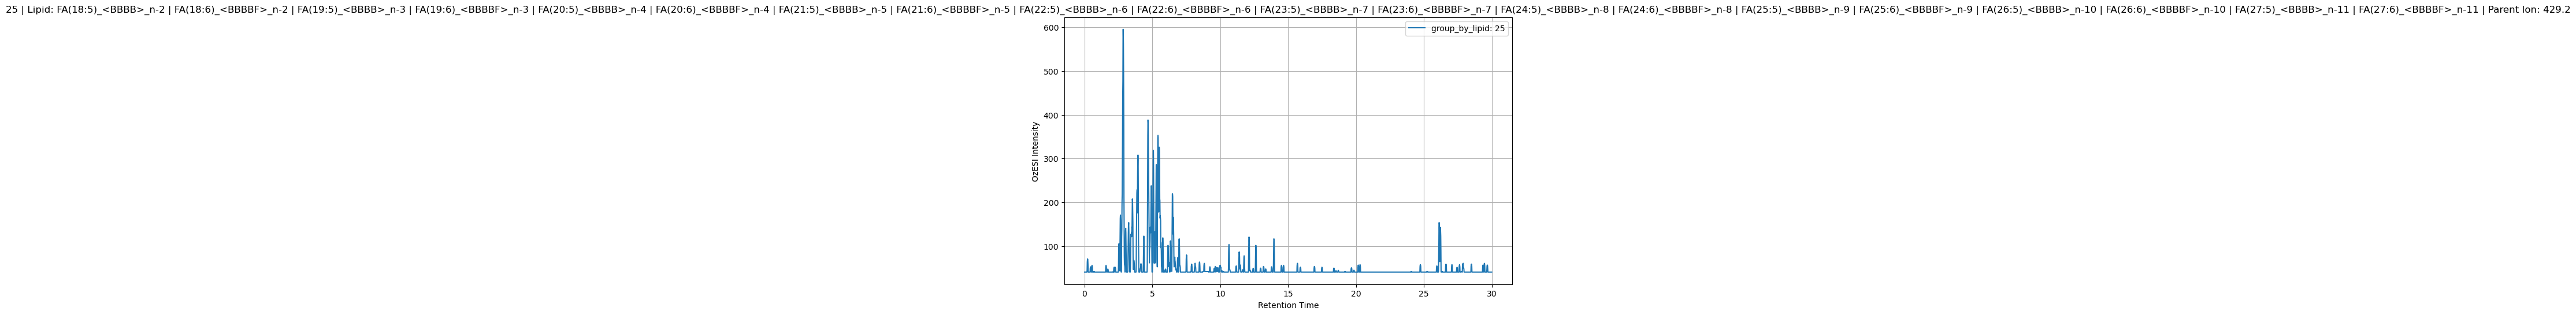

In [3]:
import matplotlib.pyplot as plt

# Function to plot chromatograms, with options to either display or save the plots
def plot_chromatograms(df, save_path=None, show_only=False, specific_group=None):
    if specific_group:
        # If a specific group is provided, filter the DataFrame for that group only
        group_data = df[df['group_by_lipid'] == specific_group]
        
        # Ensure the Retention_Time is sorted
        group_data = group_data.sort_values(by='Retention_Time')
        
        # Extract Lipid and Parent Ion values from the first row of the group
        lipid = group_data['Lipid'].iloc[0] if not group_data.empty else f"Unknown_Lipid_{specific_group}"
        parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
        
        plt.figure(figsize=(10, 6))
        plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'group_by_lipid: {specific_group}')
        plt.xlabel('Retention Time')
        plt.ylabel('OzESI Intensity')
        
        # Add Lipid and Parent Ion to the title
        plt.title(f'{specific_group} | Lipid: {lipid} | Parent Ion: {parent_ion}')
        
        plt.legend()
        plt.grid(True)
        
        if show_only:
            plt.show()  # Display the plot
        else:
            # Save the plot as a PNG with the lipid name followed by "_OFF"
            save_file = f"{save_path}/{lipid.replace(':', '_').replace('/', '_')}_OFF.png"  # Clean filename
            plt.savefig(save_file)
            print(f"Plot saved as {save_file}")
        plt.close()  # Close the figure after displaying or saving

    else:
        # Iterate through each unique group_by_lipid value if no specific group is provided
        for group_value in df['group_by_lipid'].unique():
            group_data = df[df['group_by_lipid'] == group_value]
            
            # Ensure the Retention_Time is sorted
            group_data = group_data.sort_values(by='Retention_Time')
            
            # Extract Lipid and Parent Ion values from the first row of the group
            lipid = group_data['Lipid'].iloc[0] if not group_data.empty else f"Unknown_Lipid_{group_value}"
            parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
            
            plt.figure(figsize=(10, 6))
            plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'group_by_lipid: {group_value}')
            plt.xlabel('Retention Time')
            plt.ylabel('OzESI Intensity')
            
            # Add Lipid and Parent Ion to the title
            plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion}')
            
            plt.legend()
            plt.grid(True)
            
            if show_only:
                plt.show()  # Display the plot
                break  # Exit after showing one plot if in "show only" mode
            else:
                # Save the plot as a PNG with the lipid name followed by "_OFF"
                save_file = f"{save_path}/{lipid.replace(':', '_').replace('/', '_')}_OFF.png"  # Clean filename
                plt.savefig(save_file)
                print(f"Plot saved as {save_file}")
            plt.close()  # Close the figure to avoid overlap in the next iteration

# Example usage:
# User-defined variable for the save path
save_path = 'Projects/AMP/plots/OFF_plots/'  # Replace with your desired save path

# # Call the function to either display or save chromatograms
# # For saving and iterating through all groups:
# plot_chromatograms(df, save_path=save_path)

# For showing only a specific group without saving:
plot_chromatograms(df_before, show_only=True, specific_group=25)


# 5 - Analysis

In [5]:
!sbatch core/backend/not_possible/analysis_5_AMP_OFF_notpossible.sh

Submitted batch job 20384334


In [55]:
# import pandas as pd
# df = pd.read_parquet('Projects/STD/analysis/OFF/multiple_values/df_analysis_5_FAME_OFF.parquet')
#  #Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF.parquet
# print(df['Lipid'].unique())
# df.head(10)
import pandas as pd
df = pd.read_parquet('Projects/AMP/analysis/OFF/notpossible/df_analysis_5_hippo_WT_m1_FAD245_OFF.parquet')
# pd.read_parquet('core/python/')
# df = df[(df['Retention_Time'] >= 6.4) & (df['Retention_Time'] <= 7.9)]
df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column
0,FA(d2-16:0),3.558550,2066.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,16:0,FA,None,7.899783,2066.0,0.061851,0.064600,133.463600,group_by_lipid
1,FA(d2-16:0),4.075367,3753.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,16:0,FA,None,7.899783,3753.0,0.171538,0.167967,630.378900,group_by_lipid
2,FA(d2-16:0),4.269167,1074.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,16:0,FA,None,7.899783,1074.0,0.051899,0.051667,55.490000,group_by_lipid
3,FA(d2-16:0),7.899783,1019577.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,16:0,FA,None,7.899783,1019577.0,0.171566,0.180883,184424.486350,group_by_lipid
4,FA(d2-16:0),8.558717,2783.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,16:0,FA,None,7.899783,2783.0,0.041116,0.038750,107.841250,group_by_lipid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,FA(5:0) | FA(6:1)_<>_n-2 | FA(6:2)_<F>_n-2 | F...,2.310767,2330.0,3,44,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,269.1 -> 183.0,hippo_WT_m1_FAD245,269.1,183.0,5:0|6:1|6:2|7:1|7:2|7:3|8:1|8:2|8:3|8:4|9:1|9:...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,2330.0,0.038104,0.038767,90.326333,group_by_lipid
479,FA(5:0) | FA(6:1)_<>_n-2 | FA(6:2)_<F>_n-2 | F...,2.659617,136973.0,3,44,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,269.1 -> 183.0,hippo_WT_m1_FAD245,269.1,183.0,5:0|6:1|6:2|7:1|7:2|7:3|8:1|8:2|8:3|8:4|9:1|9:...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,136973.0,0.086414,0.090450,12389.207850,group_by_lipid
480,FA(6:1)_<>_n-3 | FA(6:2)_<F>_n-3 | FA(6:3)_<FF...,0.670083,1765.0,2,46,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,255.2 -> 183.0,hippo_WT_m1_FAD245,255.2,183.0,6:1|6:2|6:3|7:1|7:2|7:3|7:4|8:1|8:2|8:3|8:4|8:...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,1765.0,0.089125,0.090433,159.614833,group_by_lipid
481,FA(6:1)_<>_n-3 | FA(6:2)_<F>_n-3 | FA(6:3)_<FF...,1.677867,5115.0,2,46,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,255.2 -> 183.0,hippo_WT_m1_FAD245,255.2,183.0,6:1|6:2|6:3|7:1|7:2|7:3|7:4|8:1|8:2|8:3|8:4|8:...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,5115.0,0.210242,0.206717,1057.355750,group_by_lipid


# STD RT Adjustment

In [56]:
def STD_RT_Adjustment(ozon_df, fame_std):
    """
    Calculates the difference between STD_RT_OFF in ozon_df for each unique Sample_ID
    with the reference STD_RT_OFF from fame_std and applies the same difference to all rows for that Sample_ID.
    Creates a new column 'Adjusted_RT_FAME' which is the sum of 'Retention_Time' and 'STD_RT_Dif_FAME'.
    
    Assumes fame_std contains only one reference STD_RT_OFF value.
    """
    # Get the reference STD_RT_OFF value from fame_std
    reference_std_rt_off = fame_std['STD_RT_OFF'].iloc[0]
    print(f"Reference STD_RT_OFF: {reference_std_rt_off}")

    # Create a dictionary to store STD_RT_Dif_FAME for each unique Sample_ID
    std_rt_diff_dict = {}
    
    # Calculate the difference for each unique Sample_ID in ozon_df
    for sample_id in ozon_df['Sample_ID'].unique():
        sample_std_rt_off = ozon_df.loc[ozon_df['Sample_ID'] == sample_id, 'STD_RT_OFF'].iloc[0]
        std_rt_diff_dict[sample_id] = sample_std_rt_off - reference_std_rt_off
        print(f"Sample_ID: {sample_id}, STD_RT_OFF: {sample_std_rt_off}, "
              f"STD_RT_Dif_FAME: {std_rt_diff_dict[sample_id]}")
    
    # Apply the calculated difference to all rows based on Sample_ID
    ozon_df['STD_RT_Dif_FAME'] = ozon_df['Sample_ID'].map(std_rt_diff_dict)
    print("STD_RT_Dif_FAME column populated with RT differences per Sample_ID.")
    
    # Calculate Adjusted_RT_FAME as Retention_Time + STD_RT_Dif_FAME
    ozon_df['Adjusted_RT_FAME'] = ozon_df['Retention_Time'] + ozon_df['STD_RT_Dif_FAME']
    print("Adjusted_RT_FAME column created with adjusted retention times.")

# Example usage:
# STD_RT_Adjustment(ozon_df, fame_std)


In [57]:
fame_std = pd.read_parquet('Projects/STD/off_possible/FAME_off_possible_top2.parquet')
fame_std = fame_std[fame_std['Species'].str.contains('16:1', case=False, na=False)]
fame_std

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
4,FA(16:1),6.910983,1813371.0,28,19,FAME_off,421.4 -> 183.0,FAME,421.4,183.0,16:1,FA,FAME,8.169267,1813371.0,0.104408,0.104933,190283.0636,group_by_lipid,1


In [61]:
STD_RT_Adjustment(df, fame_std)
df.to_parquet('Projects/AMP/notpossible/rt_adjustment_6/df_rt_adjustment_6_hippo_WT_m1_FAD245_OFF.parquet')
df

Reference STD_RT_OFF: 8.169266666666667
Sample_ID: 11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3off_01, STD_RT_OFF: 7.899783333333334, STD_RT_Dif_FAME: -0.2694833333333335
STD_RT_Dif_FAME column populated with RT differences per Sample_ID.
Adjusted_RT_FAME column created with adjusted retention times.


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_Dif_FAME,Adjusted_RT_FAME
0,FA(d2-16:0),3.558550,2066.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,...,FA,None,7.899783,2066.0,0.061851,0.064600,133.463600,group_by_lipid,-0.269483,3.289067
1,FA(d2-16:0),4.075367,3753.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,...,FA,None,7.899783,3753.0,0.171538,0.167967,630.378900,group_by_lipid,-0.269483,3.805883
2,FA(d2-16:0),4.269167,1074.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,...,FA,None,7.899783,1074.0,0.051899,0.051667,55.490000,group_by_lipid,-0.269483,3.999683
3,FA(d2-16:0),7.899783,1019577.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,...,FA,None,7.899783,1019577.0,0.171566,0.180883,184424.486350,group_by_lipid,-0.269483,7.630300
4,FA(d2-16:0),8.558717,2783.0,30,52,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,425.4 -> 183.0,hippo_WT_m1_FAD245,425.4,183.0,...,FA,None,7.899783,2783.0,0.041116,0.038750,107.841250,group_by_lipid,-0.269483,8.289233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,FA(5:0) | FA(6:1)_<>_n-2 | FA(6:2)_<F>_n-2 | F...,2.310767,2330.0,3,44,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,269.1 -> 183.0,hippo_WT_m1_FAD245,269.1,183.0,...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,2330.0,0.038104,0.038767,90.326333,group_by_lipid,-0.269483,2.041283
479,FA(5:0) | FA(6:1)_<>_n-2 | FA(6:2)_<F>_n-2 | F...,2.659617,136973.0,3,44,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,269.1 -> 183.0,hippo_WT_m1_FAD245,269.1,183.0,...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,136973.0,0.086414,0.090450,12389.207850,group_by_lipid,-0.269483,2.390133
480,FA(6:1)_<>_n-3 | FA(6:2)_<F>_n-3 | FA(6:3)_<FF...,0.670083,1765.0,2,46,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,255.2 -> 183.0,hippo_WT_m1_FAD245,255.2,183.0,...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,1765.0,0.089125,0.090433,159.614833,group_by_lipid,-0.269483,0.400600
481,FA(6:1)_<>_n-3 | FA(6:2)_<F>_n-3 | FA(6:3)_<FF...,1.677867,5115.0,2,46,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,255.2 -> 183.0,hippo_WT_m1_FAD245,255.2,183.0,...,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,5115.0,0.210242,0.206717,1057.355750,group_by_lipid,-0.269483,1.408383


# 6 - FILTER BY FAME UPDATEING Nov6

In [64]:
import pandas as pd
import os
import re

def filter_OzOFF_by_fame_std(input_dir, fame_std, output_dir, fame_rt_window=0.5):
    """
    Filters parquet files in the input directory based on fame_std retention times and species,
    using Adjusted_RT_FAME from the input files to compare against fame_std Retention_Time.
    Updates Species to only contain the matched species and saves the filtered result as parquet files
    in the output directory. Logs and removed lipids CSVs are saved in a log directory inside the output directory.
    """
    
    def filter_fa_16_1(df):
        """
        Filters DataFrame rows where the Lipid column contains 'FA(16:1)'.
        Keeps only the 'FA(16:1)' entries along with any trailing details, removing other lipid types.
        """
        # Pattern to match 'FA(16:1)' along with any extra parts that follow it
        pattern = r'\bFA\(16:1\)(?:_[^|]*)?'

        # Filter rows where 'FA(16:1)' is present in the Lipid column
        filtered_df = df[df['Lipid'].str.contains(pattern, regex=True)]
        print(f"Number of rows matching FA(16:1): {len(filtered_df)}")

        # Update the Lipid column to keep only 'FA(16:1)' entries with any trailing details
        filtered_df['Lipid'] = filtered_df['Lipid'].apply(lambda x: '|'.join(re.findall(pattern, x)))
        print("Updated Lipid column to retain only 'FA(16:1)' values with details.")

        return filtered_df

    print("Starting filter_OzOFF_by_fame_std function")
    print(f"Input directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Retention time window: {fame_rt_window}")
    print(f"Fame standard DataFrame columns: {fame_std.columns.tolist()}")

    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Create a log subdirectory inside the output directory
    log_dir = os.path.join(output_dir, 'log')
    os.makedirs(log_dir, exist_ok=True)

    # Check if input directory has parquet files
    input_files = [f for f in os.listdir(input_dir) if f.endswith(".parquet")]
    print(f"Number of parquet files found in input directory: {len(input_files)}")
    if not input_files:
        print("No parquet files found in input directory. Exiting function.")
        return

    # Iterate over all parquet files in the input directory
    for parquet_file in input_files:
        print(f"Processing file: {parquet_file}")

        # Read the parquet file
        file_path = os.path.join(input_dir, parquet_file)
        filtered_ozON = pd.read_parquet(file_path)

        # Add Lipid_Possible column as a copy of Lipid
        filtered_ozON['Lipid_Possible'] = filtered_ozON['Lipid']
        print("Lipid_Possible column created")

        # Apply the FA(16:1) filter using the inner function
        filtered_ozON = filter_fa_16_1(filtered_ozON)

        # Check the initial data after applying the FA(16:1) filter
        print(f"Rows after FA(16:1) filter: {len(filtered_ozON)}")
        print(f"filtered_ozON columns: {filtered_ozON.columns.tolist()}")

        # Create a new DataFrame to store the filtered ozON data
        filtered_ozON_result = filtered_ozON.copy()

        # Prepare lists for logging
        drop_indices = []
        removed_lipids = []

        # Get sample name from Sample column
        sample_name = filtered_ozON_result['Sample'].unique()[0]
        log_filename = f"{sample_name}_fame_filter_log_debug.txt"
        log_file_path = os.path.join(log_dir, log_filename)

        # CSV filename for removed lipids
        csv_filename = f"{sample_name}_fame_filter_removed_lipids_debug.csv"
        csv_file_path = os.path.join(log_dir, csv_filename)

        # Iterate through each entry in fame_std to filter ozON entries
        for _, fame_entry in fame_std.iterrows():
            fame_std_rt = fame_entry['Retention_Time']
            fame_std_species = fame_entry['Species']
            print(f"Processing fame_std entry: Retention_Time={fame_std_rt}, Species={fame_std_species}")

            # Define bounds for Adjusted_RT_FAME comparison
            rt_lower_bound = fame_std_rt - fame_rt_window
            rt_upper_bound = fame_std_rt + fame_rt_window
            print(f"Adjusted RT bounds: {rt_lower_bound} to {rt_upper_bound}")

            # Filter entries within the defined Adjusted_RT_FAME window and matching Species
            for index, row in filtered_ozON_result.iterrows():
                adjusted_rt = row['Adjusted_RT_FAME']
                species_list = row['Species'].split('|')  # Split species by '|'

                print(f"Row {index}: Adjusted_RT_FAME={adjusted_rt}, Species={row['Species']}")
                print(f"Species list after split: {species_list}")

                # Check if fame_std_species is in the species_list and adjusted_rt is within bounds
                if fame_std_species in species_list and rt_lower_bound <= adjusted_rt <= rt_upper_bound:
                    print(f"Match found for row {index}: Adjusted_RT_FAME within bounds and Species match")
                    # Update Species column to contain only the matched fame_std_species
                    filtered_ozON_result.at[index, 'Species'] = fame_std_species
                    print(f"Updated Species for row {index} to: {fame_std_species}")
                else:
                    # If it doesn't match, log the row for removal
                    rt_diff = min(abs(adjusted_rt - rt_lower_bound), abs(adjusted_rt - rt_upper_bound))
                    print(f"No match for row {index}: RT difference={rt_diff}, Species mismatch or RT out of bounds")
                    drop_indices.append(index)
                    removed_lipids.append({
                        'Lipid': row['Lipid'],
                        'Adjusted_RT_FAME': adjusted_rt,
                        'Ground_Truth_RT': fame_std_rt,
                        'Species': row['Species'],
                        'Ground_Truth_Species': fame_std_species,
                        'RT_Difference': rt_diff
                    })

        # Drop all collected indices
        filtered_ozON_result = filtered_ozON_result.drop(drop_indices).reset_index(drop=True)
        print(f"Filtered rows in {sample_name}: {len(drop_indices)} removed")

        # Save filtered DataFrame and removed lipids log to CSV
        filtered_ozON_result.to_parquet(os.path.join(output_dir, f"{sample_name}_filtered.parquet"))
        pd.DataFrame(removed_lipids).to_csv(csv_file_path, index=False)

        # Write log entries to a text file
        with open(log_file_path, 'w') as log_file:
            for entry in removed_lipids:
                log_file.write(str(entry) + '\n')
            print(f"Log for removed lipids saved at: {log_file_path}")

    print("filter_OzOFF_by_fame_std function completed.")


In [69]:
# from core.python.fame_filter_AMP_7 import filter_ozon_by_fame_std
import pandas as pd

# Define input and output directories
#input_dir = 'Projects/AMP/analysis/OFF/notpossible/'
input_dir = 'Projects/AMP/notpossible/rt_adjustment_6/'
output_dir = 'Projects/AMP/fame_filter_7/notpossible_nov6/'


# Call the function with custom fame_rt_window and parent_ion_tolerance
filter_OzOFF_by_fame_std(input_dir, fame_std, output_dir, fame_rt_window=0.5)


Starting filter_OzOFF_by_fame_std function
Input directory: Projects/AMP/notpossible/rt_adjustment_6/
Output directory: Projects/AMP/fame_filter_7/notpossible_nov6/
Retention time window: 0.5
Fame standard DataFrame columns: ['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion', 'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion', 'Product_Ion', 'Species', 'Class', 'STD', 'STD_RT_OFF', 'Peak_Height', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column', 'Isomer']
Number of parquet files found in input directory: 1
Processing file: df_rt_adjustment_6_hippo_WT_m1_FAD245_OFF.parquet
Lipid_Possible column created
Number of rows matching FA(16:1): 115
Updated Lipid column to retain only 'FA(16:1)' values with details.
Rows after FA(16:1) filter: 115
filtered_ozON columns: ['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion', 'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion', 'Product_Ion', 'Species', 'Class', 'STD', 'STD_RT_OFF', 'Peak_Height

/home/iyer95/.conda/envs/CLAW/lib/python3.7/site-packages/ipykernel_launcher.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Std RT adjustment

In [70]:
step7 = pd.read_parquet('Projects/AMP/fame_filter_7/notpossible_nov6/hippo_WT_m1_FAD245_filtered.parquet')
step7


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_Dif_FAME,Adjusted_RT_FAME,Lipid_Possible
0,FA(16:1)_<>_n-2,6.724850,4029.0,26,13,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,None,7.899783,4029.0,0.046318,0.051667,208.165000,group_by_lipid,-0.269483,6.455367,FA(15:0) | FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 ...
1,FA(16:1)_<>_n-2,6.918667,1668488.0,26,13,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,None,7.899783,1668488.0,0.146934,0.142117,237119.952933,group_by_lipid,-0.269483,6.649183,FA(15:0) | FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 ...
2,FA(16:1)_<>_n-2,7.009100,1227931.0,26,13,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,None,7.899783,1227931.0,0.035132,0.025833,31721.550833,group_by_lipid,-0.269483,6.739617,FA(15:0) | FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 ...
3,FA(16:1)_<>_n-2,7.177067,2301793.0,26,13,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,None,7.899783,2301793.0,0.095411,0.103367,237928.669767,group_by_lipid,-0.269483,6.907583,FA(15:0) | FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 ...
4,FA(16:1)_<>_n-3,7.100367,10104.0,22,10,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,None,7.899783,10104.0,0.047203,0.038767,391.698400,group_by_lipid,-0.269483,6.830883,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...
5,FA(16:1)_<>_n-3,7.307083,5942.0,22,10,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,None,7.899783,5942.0,0.055603,0.051683,307.102367,group_by_lipid,-0.269483,7.037600,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...
6,FA(16:1)_<>_n-3,7.397533,5607.0,22,10,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,None,7.899783,5607.0,0.028146,0.025833,144.847500,group_by_lipid,-0.269483,7.128050,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...
7,FA(16:1)_<>_n-3,7.643017,4473.0,22,10,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,None,7.899783,4473.0,0.112408,0.103350,462.284550,group_by_lipid,-0.269483,7.373533,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...
8,FA(16:1)_<>_n-7,6.960483,3850.0,11,1,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,None,7.899783,3850.0,0.081412,0.077533,298.503333,group_by_lipid,-0.269483,6.691000,FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 ...
9,FA(16:1)_<>_n-7,7.257650,2460.0,11,1,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,None,7.899783,2460.0,0.072872,0.077533,190.732000,group_by_lipid,-0.269483,6.988167,FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 ...


# plot

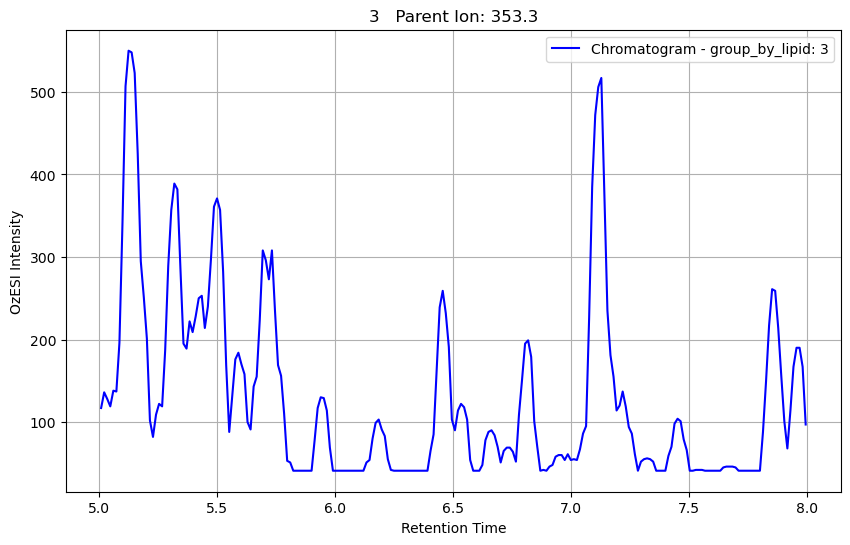

In [17]:
import matplotlib.pyplot as plt

# Function to plot the chromatogram for a specific group_by_lipid value, including analysis data (peaks)
def plot_chromatogram(df_grouped, df_analysis, group_value):
    """
    Plot the chromatogram for a specific group_by_lipid value with a Retention_Time > 5 filter.

    :param df_grouped: DataFrame containing the original grouped data.
    :param df_analysis: DataFrame containing the analyzed data (peaks).
    :param group_value: The specific group_by_lipid value to plot.
    """
    # Filter data for the specific group_by_lipid value and Retention_Time between 5 and 8
    group_data = df_grouped[(df_grouped['group_by_lipid'] == group_value) & 
                            (df_grouped['Retention_Time'] > 5) & 
                            (df_grouped['Retention_Time'] < 8)]
    
    analysis_data = df_analysis[(df_analysis['group_by_lipid'] == group_value) & 
                                (df_analysis['Retention_Time'] > 5) & 
                                (df_analysis['Retention_Time'] < 8)]
    
    # Ensure the Retention_Time is sorted in both DataFrames
    group_data = group_data.sort_values(by='Retention_Time')
    analysis_data = analysis_data.sort_values(by='Retention_Time')

    # Extract Lipid, Parent Ion, and Isomer values from the first row of the group
    lipid = group_data['Lipid'].iloc[0] if not group_data.empty else "Unknown Lipid"
    parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
    
    # Plot the grouped data (original chromatogram)
    plt.figure(figsize=(10, 6))
    plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'Chromatogram - group_by_lipid: {group_value}', color='blue')
    
    # Overlay the analysis data (peaks)
    if not analysis_data.empty:
        plt.scatter(analysis_data['Retention_Time'], analysis_data['OzESI_Intensity'], color='red', marker='x', label='Identified Peaks')

    # Add labels and title
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    
    # Add Lipid and Parent Ion to the title
    plt.title(f'{group_value}   Parent Ion: {parent_ion}')
    
    # Add a legend and grid
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Example: Define the specific group_by_lipid value you are interested in
specific_group_by_lipid_value = 3 # Replace with the actual value you are interested in

# Call the function to plot the chromatogram and analysis data with Retention_Time filter
plot_chromatogram(df_before, df, specific_group_by_lipid_value)


In [13]:
# Filter for Species containing '16:1', Retention_Time within the specified range, and OzESI_Intensity > 5000
notpossible_lipids = df[(df['Species'].str.contains('18:1', case=False, na=False)) & 
                        (df['Retention_Time'] >= 7.5) & 
                        (df['Retention_Time'] <= 9.9) &
                        (df['OzESI_Intensity'] > 500)]

sorted_notpossible_lipids = notpossible_lipids.sort_values(by='OzESI_Intensity', ascending=False)
#print unique Lipid values
#print(sorted_notpossible_lipids['Lipid'].unique())
sorted_notpossible_lipids = sorted_notpossible_lipids.nlargest(10, 'OzESI_Intensity')
sorted_notpossible_lipids


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column


# match notpossible OzOFF to regular OzOFF data - DONT ACTUALLY NEED THIS

In [12]:
# sorted_notpossible_lipids # not possible ozoff 16:1

# ozoff_df = pd.read_parquet('Projects/AMP/analysis/OFF/df_analysis_5_hippo_WT_m1_FAD245_OFF.parquet')
# ozoff_df = ozoff_df[ozoff_df['Species'].str.contains('16:1', case=False, na=False)]
# ozoff_df = ozoff_df.nlargest(2, 'OzESI_Intensity')
# ozoff_df

NameError: name 'sorted_notpossible_lipids' is not defined

In [116]:
# import pandas as pd
# import re
# from tqdm import tqdm

# def extract_core_lipid(lipid):
#     # Extract the core part of the lipid (e.g., "FA(16:1)" from "FA(16:1)_<>_n-3")
#     match = re.match(r'^(FA\(\d+:\d+\))', lipid)
#     return match.group(1) if match else lipid

# def notpossible_vs_ozoff_6(sorted_notpossible_lipids, ozoff_df):
#     # Define the retention time tolerance
#     tolerance = 0.1
    
#     # Create a new DataFrame to store matched rows
#     matched_df = pd.DataFrame()

#     # Iterate over rows in sorted_notpossible_lipids with tqdm
#     for _, not_possible_row in tqdm(sorted_notpossible_lipids.iterrows(), total=len(sorted_notpossible_lipids), desc="Processing not_possible_df rows"):
#         # Store the original Lipid values in the new column `all_possible_lipids`
#         all_possible_lipids = not_possible_row['Lipid']
        
#         # Split the Lipid values in sorted_notpossible_lipids based on '|'
#         lipid_values = all_possible_lipids.split('|')
#         species_values = not_possible_row['Species'].split('|')
        
#         # Loop through each lipid in the parsed list
#         for i, lipid in enumerate(lipid_values):
#             lipid = lipid.strip()  # Remove extra spaces
#             core_lipid = extract_core_lipid(lipid)  # Extract core lipid name
#             species = species_values[i].strip()  # Corresponding species for debugging
            
#             # Debug print for lipid and species being checked
#             # print(f"Checking Lipid: '{core_lipid}', Species: '{species}' from not_possible_row")

#             # Search for this lipid in ozoff_df within the retention time window with tqdm
#             for _, ozoff_row in tqdm(ozoff_df.iterrows(), total=len(ozoff_df), desc="Matching ozoff_df rows", leave=False):
#                 # Debug print for ozoff lipid and retention time
#                 # print(f"Comparing with ozoff Lipid: '{ozoff_row['Lipid']}', RT: {ozoff_row['Retention_Time']}, OzESI_Intensity: {ozoff_row['OzESI_Intensity']}")
                
#                 # Use direct string comparison for lipid and float comparison for retention time
#                 lipid_match = core_lipid == ozoff_row['Lipid']
#                 rt_match = abs(float(not_possible_row['Retention_Time']) - float(ozoff_row['Retention_Time'])) <= tolerance

#                 # Print match results for lipid and retention time
#                 # print(f"Lipid Match: {lipid_match}, RT Match: {rt_match}")
                
#                 if lipid_match and rt_match:
#                     # Create a new row with only matched lipid and species
#                     new_row = not_possible_row.copy()
#                     new_row['Lipid'] = lipid
#                     new_row['Species'] = species
#                     new_row['all_possible_lipids'] = all_possible_lipids  # Add original Lipid values
                    
#                     # Append to the matched DataFrame
#                     matched_df = pd.concat([matched_df, new_row.to_frame().T], ignore_index=True)
                    
#                     # Print debug statement showing match details
#                     # print(f"Match found and appended: Lipid = {lipid}, Species = {species}, Retention Time = {ozoff_row['Retention_Time']}, All Possible Lipids = {all_possible_lipids}")
#                     break  # Exit once a match is found for this lipid
#                 # else:
#                     # print("No match for this ozoff row.")
    
#     # Final debug output
#     # print("Matching complete.")
#     if matched_df.empty:
#         print("No matches were found.")
#     else:
#         print(f"Total matches found: {len(matched_df)}")
    
#     return matched_df

# # Call the function with your DataFrames
# matched_df = notpossible_vs_ozoff_6(sorted_notpossible_lipids, ozoff_df)

# # Display the resulting matched DataFrame
# matched_df


Processing not_possible_df rows: 100%|██████████| 5/5 [00:01<00:00,  3.70it/s]

Total matches found: 2


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,all_possible_lipids
0,FA(18:1)_<>_n-2,9.03615,3224463.0,33,20,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,437.4 -> 183.0,hippo_WT_m1_FAD245,437.4,183.0,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,3224463.0,0.117766,0.116267,374897.5648,group_by_lipid,FA(17:0) | FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 ...
1,FA(18:1)_<>_n-3,8.9207,39933.0,29,16,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,423.3 -> 183.0,hippo_WT_m1_FAD245,423.3,183.0,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,39933.0,0.05508,0.051667,2063.205,group_by_lipid,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...


In [117]:
# matched_df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,all_possible_lipids
0,FA(18:1)_<>_n-2,9.03615,3224463.0,33,20,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,437.4 -> 183.0,hippo_WT_m1_FAD245,437.4,183.0,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,3224463.0,0.117766,0.116267,374897.5648,group_by_lipid,FA(17:0) | FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 ...
1,FA(18:1)_<>_n-3,8.9207,39933.0,29,16,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,423.3 -> 183.0,hippo_WT_m1_FAD245,423.3,183.0,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,7.899783,39933.0,0.05508,0.051667,2063.205,group_by_lipid,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...


# DO MORE WORK HERE NEXT

# OzOFF notpossbile - Remove OzON not possible  | LOAD OZON HERE

In [73]:
import pandas as pd
ozon_test = pd.read_parquet('Projects/AMP/fame_filter_7/hippo_WT_m1_FAD245_fame_filter_7.parquet')
ozon_test = pd.read_parquet('Projects/AMP/isomer_filter_6/hippo_WT_m1_FAD245_isomer_filtered_6.parquet')

filtered_lipids = ozon_test[ozon_test['Lipid'].str.contains('16:1', case=False, na=False)]
sorted_filtered_lipids_OZON = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
print(sorted_filtered_lipids_OZON['Species'].unique())
sorted_filtered_lipids_OZON = sorted_filtered_lipids_OZON.sort_values(by='Lipid', ascending=True)
sorted_filtered_lipids_OZON


# ozon_test

['16:1']


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Slope_Left,Slope_Right,Biology,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer
76,FA(16:1)_<>_n-10,7.039200,2658.0,4,81,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,4.168539e+04,-2.796314e+04,hippo,WT,FAD245,m1,10,7.077967,10,2.0
68,FA(16:1)_<>_n-2,7.138283,1137226.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,1.915522e+07,-6.663993e+06,hippo,WT,FAD245,m1,2,7.177050,2,2.0
66,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,1.434060e+07,-1.149128e+07,hippo,WT,FAD245,m1,2,6.931567,2,2.0
77,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,1.434060e+07,-1.149128e+07,hippo,WT,FAD245,m1,2,6.931567,2,1.0
67,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,-3.180940e+05,-3.513944e+06,hippo,WT,FAD245,m1,2,7.009083,2,2.0
78,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,-3.180940e+05,-3.513944e+06,hippo,WT,FAD245,m1,2,7.009083,2,1.0
79,FA(16:1)_<>_n-3,6.854850,10899.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,4.303410e+04,-1.137442e+04,hippo,WT,FAD245,m1,3,6.893617,3,1.0
70,FA(16:1)_<>_n-5,7.101567,566.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,-6.089056e+02,-5.935323e+03,hippo,WT,FAD245,m1,5,7.140333,5,2.0
69,FA(16:1)_<>_n-5,7.062800,553.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,5.905991e+03,-6.089056e+02,hippo,WT,FAD245,m1,5,7.101567,5,2.0
71,FA(16:1)_<>_n-6,7.063417,920.0,12,90,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,1.059539e+04,6.735892e+01,hippo,WT,FAD245,m1,6,7.102183,6,2.0


In [6]:
# import pandas as pd

# def match_lipids(sorted_notpossible_lipids, ozon_test):
#     # Create a new column in the OFF data to store matched information
#     sorted_notpossible_lipids['Matched_Lipid_ON'] = None

#     # Iterate through each row in the ON data
#     for index_on, row_on in ozon_test.iterrows():
#         on_lipid = row_on['Lipid'].strip()  # Trim spaces for accurate matching
#         match_found = False

#         # Iterate through each row in the OFF data
#         for index_off, row_off in sorted_notpossible_lipids.iterrows():
#             # Split the OFF Lipid values by '|' and trim each part
#             off_lipids = [lipid.strip() for lipid in row_off['Lipid'].split('|')]

#             # Check if the ON lipid matches any of the possible OFF lipids
#             if any(on_lipid.lower() == off_lipid.lower() for off_lipid in off_lipids):
#                 # If a match is found, update the 'Matched_Lipid_ON' column in the OFF DataFrame
#                 sorted_notpossible_lipids.at[index_off, 'Matched_Lipid_ON'] = on_lipid
#                 match_found = True
#                 break  # Stop searching for this ON lipid once a match is found

#         # If no match is found, you can choose to log or handle this scenario
#         if not match_found:
#             print(f"No match found for ON lipid: {on_lipid}")

#     # Filter the OFF data to only keep rows with matched Lipids
#     matched_lipids = sorted_notpossible_lipids.dropna(subset=['Matched_Lipid_ON']).copy()

#     return matched_lipids

# # Example usage
# # Assuming sorted_notpossible_lipids and ozon_test are the input DataFrames
# matched_lipids_df = match_lipids(sorted_notpossible_lipids, ozon_test)

# # Display or save the result
# matched_lipids_df
# # matched_lipids_df.to_csv('matched_lipids.csv', index=False)


In [81]:
import pandas as pd

def match_lipids_with_adjusted_rt_to_rt(ozon_test, sorted_notpossible_lipids, rt_window=0.5):
    # Create new columns in the ON data to store matched information from OFF
    ozon_test['Matched_Lipid_OFF'] = None
    ozon_test['Intensity_OFF'] = None
    ozon_test['Retention_Time_OFF'] = None

    # Iterate through each row in the ON data
    for index_on, row_on in ozon_test.iterrows():
        on_lipid = row_on['Lipid'].strip()  # Trim spaces for accurate matching
        on_adjusted_rt = row_on['Adjusted_RT']  # Adjusted RT of the ON lipid
        match_found = False

        # Iterate through each row in the OFF data
        for index_off, row_off in sorted_notpossible_lipids.iterrows():
            # Split the OFF Lipid values by '|' and trim each part
            off_lipids = [lipid.strip() for lipid in row_off['Lipid'].split('|')]
            off_retention_time = row_off['Retention_Time']  # Retention time of the OFF lipid

            # Check if the ON lipid matches any of the possible OFF lipids
            # and if the Adjusted_RT is within the specified window of the Retention_Time
            if any(on_lipid.lower() == off_lipid.lower() for off_lipid in off_lipids) and abs(on_adjusted_rt - off_retention_time) <= rt_window:
                # If a match is found, update the 'Matched_Lipid_OFF', 'Intensity_OFF', and 'Retention_Time_OFF' columns in the ON DataFrame
                ozon_test.at[index_on, 'Matched_Lipid_OFF'] = row_off['Lipid']
                ozon_test.at[index_on, 'Intensity_OFF'] = row_off['OzESI_Intensity']
                ozon_test.at[index_on, 'Retention_Time_OFF'] = off_retention_time
                match_found = True
                break  # Stop searching for this ON lipid once a match is found

        # If no match is found, log or handle this scenario
        if not match_found:
            print(f"No match found for ON lipid: {on_lipid} within Adjusted_RT window {on_adjusted_rt} ± {rt_window}")

    # Filter the ON data to separate matched and unmatched lipids
    matched_lipids_df = ozon_test.dropna(subset=['Matched_Lipid_OFF']).copy()
    unmatched_lipids_df = ozon_test[ozon_test['Matched_Lipid_OFF'].isna()].copy()

    return matched_lipids_df, unmatched_lipids_df

# Example usage
# Assuming sorted_notpossible_lipids and ozon_test are the input DataFrames
matched_lipids_df, unmatched_lipids_df = match_lipids_with_adjusted_rt_to_rt(sorted_filtered_lipids_OZON, step7, rt_window=0.05)

# # Print values of Matched_Lipid_OFF in row 1 if exists
# if not matched_lipids_df.empty:
#     print(matched_lipids_df['Matched_Lipid_OFF'].iloc[1])

# Display or save the results
matched_lipids_df
unmatched_lipids_df
# matched_lipids_df.to_csv('matched_lipids.csv', index=False)
# unmatched_lipids_df.to_csv('unmatched_lipids.csv', index=False)


No match found for ON lipid: FA(16:1)_<>_n-10 within Adjusted_RT window 7.077966666666667 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-3 within Adjusted_RT window 6.8936166666666665 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-5 within Adjusted_RT window 7.140333333333333 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-5 within Adjusted_RT window 7.101566666666667 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-6 within Adjusted_RT window 7.1021833333333335 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-7 within Adjusted_RT window 6.870033333333334 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-7 within Adjusted_RT window 7.14135 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-8 within Adjusted_RT window 6.9092 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-9 within Adjusted_RT window 6.961283333333333 ± 0.05
No match found for ON lipid: FA(16:1)_<>_n-9 within Adjusted_RT window 6.961283333333333 ± 0.05


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer,Matched_Lipid_OFF,Intensity_OFF,Retention_Time_OFF
76,FA(16:1)_<>_n-10,7.039200,2658.0,4,81,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,WT,FAD245,m1,10,7.077967,10,2.0,None,None,None
79,FA(16:1)_<>_n-3,6.854850,10899.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,WT,FAD245,m1,3,6.893617,3,1.0,None,None,None
70,FA(16:1)_<>_n-5,7.101567,566.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,WT,FAD245,m1,5,7.140333,5,2.0,None,None,None
69,FA(16:1)_<>_n-5,7.062800,553.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,WT,FAD245,m1,5,7.101567,5,2.0,None,None,None
71,FA(16:1)_<>_n-6,7.063417,920.0,12,90,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,WT,FAD245,m1,6,7.102183,6,2.0,None,None,None
80,FA(16:1)_<>_n-7,6.831267,1788.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,6.870033,7,1.0,None,None,None
73,FA(16:1)_<>_n-7,7.102583,1249.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,7.141350,7,2.0,None,None,None
82,FA(16:1)_<>_n-8,6.870433,820.0,8,92,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,WT,FAD245,m1,8,6.909200,8,1.0,None,None,None
75,FA(16:1)_<>_n-9,6.922517,672.0,6,93,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,WT,FAD245,m1,9,6.961283,9,2.0,None,None,None
83,FA(16:1)_<>_n-9,6.922517,672.0,6,93,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,WT,FAD245,m1,9,6.961283,9,1.0,None,None,None


In [79]:
matched_lipids_df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer,Matched_Lipid_OFF,Intensity_OFF,Retention_Time_OFF
68,FA(16:1)_<>_n-2,7.138283,1137226.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,7.177050,2,2.0,FA(16:1)_<>_n-2,2301793.0,7.177067
66,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,6.931567,2,2.0,FA(16:1)_<>_n-2,1668488.0,6.918667
77,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,6.931567,2,1.0,FA(16:1)_<>_n-2,1668488.0,6.918667
67,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,7.009083,2,2.0,FA(16:1)_<>_n-2,1227931.0,7.0091
78,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,7.009083,2,1.0,FA(16:1)_<>_n-2,1227931.0,7.0091
81,FA(16:1)_<>_n-7,6.921700,2359.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,6.960467,7,1.0,FA(16:1)_<>_n-7,3850.0,6.960483
72,FA(16:1)_<>_n-7,6.921700,2359.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,6.960467,7,2.0,FA(16:1)_<>_n-7,3850.0,6.960483
74,FA(16:1)_<>_n-8,7.103000,1655.0,8,92,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,WT,FAD245,m1,8,7.141767,8,2.0,FA(16:1)_<>_n-8,1225.0,7.115933


# python function import same result?

In [82]:
# Jupyter Notebook Cell

# Import the function from the created Python file
from core.python.not_possible.notpossible_8_AMP import match_lipids_with_adjusted_rt_to_rt

# Define the paths to the directories containing the OzON and OzOFF DataFrames
ozon_test_path = 'Projects/AMP/fame_filter_7/'
off_data_path = 'Projects/AMP/analysis/OFF/notpossible/'

# Define the output directories for matched and unmatched results
notpossible_output_matched = 'Projects/AMP/notpossible_8/maybe/'
notpossible_output_nomatch = 'Projects/AMP/notpossible_8/yes/'

output_log_dir = 'Projects/AMP/notpossible_8/log/'

# Set the retention time window
rt_window = 0.2

# Call the function to match lipids
match_lipids_with_adjusted_rt_to_rt(
    input_dir=ozon_test_path,
    off_possible_dir=off_data_path,
    rt_window=rt_window,
    output_matched_dir=notpossible_output_matched,
    output_unmatched_dir=notpossible_output_nomatch,
    output_log_dir=output_log_dir
)


Output directory for matched files: Projects/AMP/notpossible_8/maybe/
Output directory for unmatched files: Projects/AMP/notpossible_8/yes/
Output directory for log files: Projects/AMP/notpossible_8/log/

Files in Directory 1 (OzOFF):
File: df_analysis_5_cortex_5xFAD_m2_FAD257_OFF.parquet, Key: cortex_5xFAD_m2_FAD257
File: df_analysis_5_hippo_5xFAD_m1_FAD249_OFF.parquet, Key: hippo_5xFAD_m1_FAD249
File: df_analysis_5_cortex_WT_m5_FAD263_OFF.parquet, Key: cortex_WT_m5_FAD263
File: df_analysis_5_cereb_WT_m2_FAD246_OFF.parquet, Key: cereb_WT_m2_FAD246
File: df_analysis_5_dienc_WT_m5_FAD263_OFF.parquet, Key: dienc_WT_m5_FAD263
File: df_analysis_5_cereb_5xFAD_m2_FAD257_OFF.parquet, Key: cereb_5xFAD_m2_FAD257
File: df_analysis_5_hippo_5xFAD_m2_FAD231_OFF.parquet, Key: hippo_5xFAD_m2_FAD231
File: df_analysis_5_cereb_WT_m5_FAD259_OFF.parquet, Key: cereb_WT_m5_FAD259
File: df_analysis_5_cereb_WT_m1_FAD245_OFF.parquet, Key: cereb_WT_m1_FAD245
File: df_analysis_5_cereb_WT_m4_FAD263_OFF.parquet, K

# NOT POSSIBLE

In [83]:
matched_lipids_df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer,Matched_Lipid_OFF,Intensity_OFF,Retention_Time_OFF
51,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,6.931567,2,2.0,FA(16:1)_<>_n-2,1668488.0,6.918667
58,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,6.931567,2,1.0,FA(16:1)_<>_n-2,1668488.0,6.918667
52,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,7.009083,2,2.0,FA(16:1)_<>_n-2,1668488.0,6.918667
59,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,WT,FAD245,m1,2,7.009083,2,1.0,FA(16:1)_<>_n-2,1668488.0,6.918667


# POSSIBLE

In [84]:
unmatched_lipids_df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer,Matched_Lipid_OFF,Intensity_OFF,Retention_Time_OFF
57,FA(16:1)_<>_n-10,7.039200,2658.0,4,81,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,WT,FAD245,m1,10,7.077967,10,2.0,None,None,None
60,FA(16:1)_<>_n-3,6.854850,10899.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,WT,FAD245,m1,3,6.893617,3,1.0,None,None,None
53,FA(16:1)_<>_n-5,7.062800,553.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,WT,FAD245,m1,5,7.101567,5,2.0,None,None,None
54,FA(16:1)_<>_n-6,7.063417,920.0,12,90,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,WT,FAD245,m1,6,7.102183,6,2.0,None,None,None
55,FA(16:1)_<>_n-7,6.921700,2359.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,6.960467,7,2.0,None,None,None
62,FA(16:1)_<>_n-7,6.921700,2359.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,6.960467,7,1.0,None,None,None
61,FA(16:1)_<>_n-7,6.831267,1788.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,7,6.870033,7,1.0,None,None,None
63,FA(16:1)_<>_n-8,6.870433,820.0,8,92,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,WT,FAD245,m1,8,6.909200,8,1.0,None,None,None
56,FA(16:1)_<>_n-9,6.922517,672.0,6,93,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,WT,FAD245,m1,9,6.961283,9,2.0,None,None,None
64,FA(16:1)_<>_n-9,6.922517,672.0,6,93,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,WT,FAD245,m1,9,6.961283,9,1.0,None,None,None


In [87]:
import pandas as pd
yes = pd.read_parquet('Projects/AMP/notpossible_8/yes/hippo_WT_m1_FAD245_notpossible_yes.parquet')
yes

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer,Matched_Lipid_OFF,Intensity_OFF,Retention_Time_OFF
0,FA(13:1)_<>_n-4,4.776933,631.0,10,32,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,WT,FAD245,m1,4,4.815700,4,2.0,None,None,None
1,FA(16:1)_<>_n-5,7.062800,553.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,WT,FAD245,m1,5,7.101567,5,2.0,None,None,None
2,FA(16:1)_<>_n-6,7.063417,920.0,12,90,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,WT,FAD245,m1,6,7.102183,6,2.0,None,None,None
3,FA(16:1)_<>_n-9,6.922517,672.0,6,93,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,WT,FAD245,m1,9,6.961283,9,2.0,None,None,None
4,FA(16:1)_<>_n-10,7.039200,2658.0,4,81,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,WT,FAD245,m1,10,7.077967,10,2.0,None,None,None
5,FA(16:1)_<>_n-3,6.854850,10899.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,WT,FAD245,m1,3,6.893617,3,1.0,None,None,None
6,FA(16:1)_<>_n-8,6.870433,820.0,8,92,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,WT,FAD245,m1,8,6.909200,8,1.0,None,None,None
7,FA(16:1)_<>_n-9,6.922517,672.0,6,93,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,WT,FAD245,m1,9,6.961283,9,1.0,None,None,None
8,FA(16:2)_<F>_n-5,5.822467,515.0,15,109,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,WT,FAD245,m1,5,5.861233,5,1.0,None,None,None
9,FA(16:2)_<F>_n-10,6.160617,604.0,4,101,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,WT,FAD245,m1,10,6.199383,10,2.0,None,None,None


# max intensity OzOFf possible

In [8]:
# def get_highest_intensity_per_lipid(df):
#     """
#     This function returns the rows with the highest OzESI_Intensity for each unique Lipid.

#     Parameters:
#     df (pd.DataFrame): The DataFrame containing 'Lipid' and 'OzESI_Intensity' columns.

#     Returns:
#     pd.DataFrame: A DataFrame containing the rows with the highest intensity for each lipid.
#     """
#     # Group by 'Lipid' and get the row with the highest 'OzESI_Intensity' for each lipid
#     highest_intensity_df = df.loc[df.groupby('Lipid')['OzESI_Intensity'].idxmax()]

#     return highest_intensity_df

# # Assuming df is your DataFrame
# df_highest_intensity = get_highest_intensity_per_lipid(df)
# #df_highest_intensity.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')

# df_highest_intensity.tail(10)


# get top 2 unsaturated lipids + add isomer column

In [28]:
# import pandas as pd
# import re

# def get_top_n_intensity_for_specific_fa(df, n=2):
#     """
#     This function returns the top N rows with the highest OzESI_Intensity for lipids that match the pattern FA(##:#) 
#     where the number after ':' is not 0 (e.g., FA(18:1), FA(16:2)). It also adds an 'Isomer' column to track the order
#     of lipids with the same name based on 'Retention_Time'. Additionally, it prints a list of lipids that have 2 or more isomers.

#     Parameters:
#     df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
#     n (int): The number of top rows to return for each lipid based on intensity.

#     Returns:
#     pd.DataFrame: A DataFrame containing the top N rows with the highest intensity for each lipid matching the pattern,
#     and an additional 'Isomer' column that indicates the order based on 'Retention_Time'. It also prints a list of lipids
#     that have 2 or more isomers.
#     """
#     # Define the regex pattern for FA(##:#) where the number after ':' is not 0
#     pattern = r'FA\(\d+:(?!0)\d+\)'

#     # Filter the DataFrame to only include rows where the Lipid column matches the pattern
#     df_filtered = df[df['Lipid'].apply(lambda x: bool(re.match(pattern, x)))] 

#     # Sort by 'Lipid' and 'OzESI_Intensity' in descending order
#     df_sorted = df_filtered.sort_values(by=['Lipid', 'OzESI_Intensity'], ascending=[True, False])
    
#     # Select the top N entries for each 'Lipid'
#     top_n_intensity_df = df_sorted.groupby('Lipid').head(n).reset_index(drop=True)
    
#     # Sort by 'Lipid' and 'Retention_Time' to assign the Isomer number
#     top_n_intensity_df['Isomer'] = top_n_intensity_df.groupby('Lipid')['Retention_Time'].rank(method='first').astype(int)

#     # Find lipids that have 2 or more isomers
#     lipids_with_isomers = top_n_intensity_df.groupby('Lipid').filter(lambda x: x['Isomer'].nunique() >= 2)['Lipid'].unique().tolist()

#     # Print out the lipids with 2 or more isomers
#     print("Lipids with 2 or more isomers:", lipids_with_isomers)

#     return top_n_intensity_df

# off_dir = 'Projects/AMP/analysis/OFF/'
# sav_dir = 'Projects/AMP/analysis/OFF/off_possible/'

# # Assuming df is your DataFrame
# df_top_2_intensity_specific_fa = get_top_n_intensity_for_specific_fa(df, n=2)

# df_top_2_intensity_specific_fa


# OFF possible function

In [8]:
import pandas as pd
import re
import glob
import os

def get_top_n_intensity_for_specific_fa(df, n=2, intensity_threshold=1000, retention_time_window=(1, 20)):
    """
    This function returns the top N rows with the highest OzESI_Intensity for lipids that match the pattern FA(##:#) 
    where the number after ':' is not 0 (e.g., FA(18:1), FA(16:2)). It also adds an 'Isomer' column to track the order
    of lipids with the same name based on 'Retention_Time'. Additionally, it prints a list of lipids that have 2 or more isomers.

    The function also applies a threshold filter on OzESI_Intensity and filters Retention_Time within the specified window.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
    n (int): The number of top rows to return for each lipid based on intensity.
    intensity_threshold (float): The minimum value for OzESI_Intensity to consider a row.
    retention_time_window (tuple): A tuple specifying the (min, max) range for Retention_Time.

    Returns:
    pd.DataFrame: A DataFrame containing the top N rows with the highest intensity for each lipid matching the pattern,
    and an additional 'Isomer' column that indicates the order based on 'Retention_Time'. It also prints a list of lipids
    that have 2 or more isomers.
    """
    # Define the regex pattern for FA(##:#) where the number after ':' is not 0
    pattern = r'FA\(\d+:(?!0)\d+\)'

    # Filter the DataFrame to only include rows where the Lipid column matches the pattern
    df_filtered = df[df['Lipid'].apply(lambda x: bool(re.match(pattern, x)))]

    # Apply the OzESI_Intensity threshold and the Retention_Time window filter
    df_filtered = df_filtered[
        (df_filtered['OzESI_Intensity'] >= intensity_threshold) &
        (df_filtered['Retention_Time'] >= retention_time_window[0]) &
        (df_filtered['Retention_Time'] <= retention_time_window[1])
    ]

    # Sort by 'Lipid' and 'OzESI_Intensity' in descending order
    df_sorted = df_filtered.sort_values(by=['Lipid', 'OzESI_Intensity'], ascending=[True, False])

    # Select the top N entries for each 'Lipid'
    top_n_intensity_df = df_sorted.groupby('Lipid').head(n).reset_index(drop=True)

    # Sort by 'Lipid' and 'Retention_Time' to assign the Isomer number
    top_n_intensity_df['Isomer'] = top_n_intensity_df.groupby('Lipid')['Retention_Time'].rank(method='first').astype(int)

    # Find lipids that have 2 or more isomers
    lipids_with_isomers = top_n_intensity_df.groupby('Lipid').filter(lambda x: x['Isomer'].nunique() >= 2)['Lipid'].unique().tolist()

    # Print out the lipids with 2 or more isomers
    print("Lipids with 2 or more isomers:", lipids_with_isomers)

    return top_n_intensity_df

def get_all_fa(df, intensity_threshold=1000, retention_time_window=(1, 20)):
    """
    This function returns all rows with OzESI_Intensity above a given threshold and within a specified Retention_Time window.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
    intensity_threshold (float): The minimum value for OzESI_Intensity to consider a row.
    retention_time_window (tuple): A tuple specifying the (min, max) range for Retention_Time.

    Returns:
    pd.DataFrame: A DataFrame containing all rows with OzESI_Intensity above the threshold and within the Retention_Time window.
    """
    # Apply the OzESI_Intensity threshold and the Retention_Time window filter
    df_filtered = df[
        (df['OzESI_Intensity'] >= intensity_threshold) &
        (df['Retention_Time'] >= retention_time_window[0]) &
        (df['Retention_Time'] <= retention_time_window[1])
    ]
    return df_filtered

def get_top_n_intensity_for_all_fa(df, n=2, intensity_threshold=1000, retention_time_window=(1, 20)):
    """
    This function returns the top N rows with the highest OzESI_Intensity for all lipids, including those with FA(##:0).
    It also adds an 'Isomer' column to track the order of lipids with the same name based on 'Retention_Time'.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
    n (int): The number of top rows to return for each lipid based on intensity.
    intensity_threshold (float): The minimum value for OzESI_Intensity to consider a row.
    retention_time_window (tuple): A tuple specifying the (min, max) range for Retention_Time.

    Returns:
    pd.DataFrame: A DataFrame containing the top N rows with the highest intensity for each lipid,
    and an additional 'Isomer' column that indicates the order based on 'Retention_Time'.
    """
    # Apply the OzESI_Intensity threshold and the Retention_Time window filter
    df_filtered = df[
        (df['OzESI_Intensity'] >= intensity_threshold) &
        (df['Retention_Time'] >= retention_time_window[0]) &
        (df['Retention_Time'] <= retention_time_window[1])
    ]

    # Sort by 'Lipid' and 'OzESI_Intensity' in descending order
    df_sorted = df_filtered.sort_values(by=['Lipid', 'OzESI_Intensity'], ascending=[True, False])

    # Select the top N entries for each 'Lipid'
    top_n_intensity_df = df_sorted.groupby('Lipid').head(n).reset_index(drop=True)

    # Sort by 'Lipid' and 'Retention_Time' to assign the Isomer number
    top_n_intensity_df['Isomer'] = top_n_intensity_df.groupby('Lipid')['Retention_Time'].rank(method='first').astype(int)

    return top_n_intensity_df

# Directories for input and output
off_dir = 'Projects/AMP/analysis/OFF/'
sav_dir = 'Projects/AMP/analysis/OFF/off_possible/'
sav_all_dir = 'Projects/AMP/analysis/OFF/all_lipids/all/'
sav_all_top2_dir = 'Projects/AMP/analysis/OFF/all_lipids/top2/'

# Ensure the save directories exist
os.makedirs(sav_dir, exist_ok=True)
os.makedirs(sav_all_dir, exist_ok=True)
os.makedirs(sav_all_top2_dir, exist_ok=True)

# Get a list of all parquet files in the off_dir
parquet_files = glob.glob(os.path.join(off_dir, '*.parquet'))

# Define thresholds for OzESI_Intensity and Retention_Time window
intensity_threshold = 1000  # Set the desired threshold for OzESI_Intensity
retention_time_window = (1, 20)  # Set the desired Retention_Time window (min, max)

# Iterate through each parquet file
for file_path in parquet_files:
    # Load the parquet file into a DataFrame
    df = pd.read_parquet(file_path)

    # Apply the function to get the top N intensity FA rows
    df_top_n = get_top_n_intensity_for_specific_fa(df, n=2, intensity_threshold=intensity_threshold, retention_time_window=retention_time_window)

    # Generate the new file name by appending '_offpossible' to the original file name
    base_name = os.path.basename(file_path).replace('.parquet', '_offpossible.parquet')
    save_path = os.path.join(sav_dir, base_name)

    # Save the updated DataFrame to a new parquet file
    df_top_n.to_parquet(save_path)

    print(f"Processed and saved: {save_path}")

    # Apply the function to get all FA rows
    df_all = get_all_fa(df, intensity_threshold=intensity_threshold, retention_time_window=retention_time_window)

    # Generate the new file name by appending '_alllipids' to the original file name
    base_name_all = os.path.basename(file_path).replace('.parquet', '_alllipids.csv')
    save_all_path = os.path.join(sav_all_dir, base_name_all)

    # Save the updated DataFrame to a new CSV file
    df_all.to_csv(save_all_path, index=False)

    print(f"Processed and saved: {save_all_path}")

    # Apply the function to get the top N intensity for all FA rows
    df_all_top_n = get_top_n_intensity_for_all_fa(df, n=2, intensity_threshold=intensity_threshold, retention_time_window=retention_time_window)

    # Generate the new file name by appending '_alllipids_top2' to the original file name
    base_name_all_top2 = os.path.basename(file_path).replace('.parquet', '_alllipids_top2.csv')
    save_all_top2_path = os.path.join(sav_all_top2_dir, base_name_all_top2)

    # Save the updated DataFrame to a new CSV file
    df_all_top_n.to_csv(save_all_top2_path, index=False)

    print(f"Processed and saved: {save_all_top2_path}")


Lipids with 2 or more isomers: ['FA(10:1)', 'FA(12:1)', 'FA(13:1)', 'FA(14:1)', 'FA(15:1)', 'FA(16:1)', 'FA(16:2)', 'FA(17:1)', 'FA(18:1)', 'FA(18:2)', 'FA(18:3)', 'FA(18:4)', 'FA(20:1)', 'FA(20:2)', 'FA(20:3)', 'FA(20:4)', 'FA(20:5)', 'FA(22:1)', 'FA(22:6)', 'FA(8:1)', 'FA(9:1)']
Processed and saved: Projects/AMP/analysis/OFF/off_possible/df_analysis_5_cereb_WT_m5_FAD259_OFF_offpossible.parquet
Processed and saved: Projects/AMP/analysis/OFF/all_lipids/all/df_analysis_5_cereb_WT_m5_FAD259_OFF_alllipids.csv
Processed and saved: Projects/AMP/analysis/OFF/all_lipids/top2/df_analysis_5_cereb_WT_m5_FAD259_OFF_alllipids_top2.csv
Lipids with 2 or more isomers: ['FA(10:1)', 'FA(12:1)', 'FA(13:1)', 'FA(14:1)', 'FA(14:3)', 'FA(15:1)', 'FA(16:1)', 'FA(16:2)', 'FA(17:1)', 'FA(18:1)', 'FA(18:2)', 'FA(18:3)', 'FA(18:4)', 'FA(20:1)', 'FA(20:2)', 'FA(20:3)', 'FA(20:4)', 'FA(20:5)', 'FA(22:1)', 'FA(22:6)', 'FA(8:1)', 'FA(9:1)']
Processed and saved: Projects/AMP/analysis/OFF/off_possible/df_analysis_5_c

In [2]:
import pandas as pd
test_df = pd.read_parquet('Projects/AMP/analysis/OFF/off_possible/df_analysis_5_hippo_WT_m1_FAD245_OFF_offpossible.parquet')
test_df.to_csv('Projects/AMP/analysis/OFF/off_possible/csv/df_analysis_5_hippo_WT_m1_FAD245_OFF_offpossible.csv')
test_df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
0,FA(10:1),4.027767,11770.0,10,2,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,337.2 -> 183.0,hippo_WT_m1_FAD245,337.2,183.0,10:1,FA,None,7.899783,11770.0,0.062611,0.064600,760.342000,group_by_lipid,2
1,FA(10:1),3.821050,8518.0,10,2,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,337.2 -> 183.0,hippo_WT_m1_FAD245,337.2,183.0,10:1,FA,None,7.899783,8518.0,0.071615,0.077517,660.286967,group_by_lipid,1
2,FA(12:1),4.323917,8993.0,15,6,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,365.2 -> 183.0,hippo_WT_m1_FAD245,365.2,183.0,12:1,FA,None,7.899783,8993.0,0.086871,0.090450,813.416850,group_by_lipid,2
3,FA(12:1),3.341967,6903.0,15,6,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,365.2 -> 183.0,hippo_WT_m1_FAD245,365.2,183.0,12:1,FA,None,7.899783,6903.0,0.074065,0.064600,445.933800,group_by_lipid,1
4,FA(12:2),3.600583,1352.0,14,7,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,363.3 -> 183.0,hippo_WT_m1_FAD245,363.3,183.0,12:2,FA,None,7.899783,1352.0,0.061586,0.064600,87.339200,group_by_lipid,1
5,FA(13:1),4.762600,6474.0,18,9,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,379.3 -> 183.0,hippo_WT_m1_FAD245,379.3,183.0,13:1,FA,None,7.899783,6474.0,0.091248,0.090450,585.573300,group_by_lipid,2
6,FA(13:1),3.548083,6441.0,18,9,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,379.3 -> 183.0,hippo_WT_m1_FAD245,379.3,183.0,13:1,FA,None,7.899783,6441.0,0.065524,0.064600,416.088600,group_by_lipid,1
7,FA(14:1),5.420933,36158.0,21,12,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,393.4 -> 183.0,hippo_WT_m1_FAD245,393.4,183.0,14:1,FA,None,7.899783,36158.0,0.109245,0.103367,3737.531933,group_by_lipid,2
8,FA(14:1),5.278800,18294.0,21,12,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,393.4 -> 183.0,hippo_WT_m1_FAD245,393.4,183.0,14:1,FA,None,7.899783,18294.0,0.054350,0.051683,945.494900,group_by_lipid,1
9,FA(15:1),6.182417,30465.0,25,15,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,407.3 -> 183.0,hippo_WT_m1_FAD245,407.3,183.0,15:1,FA,None,7.899783,30465.0,0.080497,0.077517,2361.545250,group_by_lipid,2


In [30]:
# import pandas as pd
# import re

# def filter_by_lipid_list(df, lipid_list):
#     """
#     This function filters the DataFrame to keep both isomers (Isomer 1 and 2) for lipids in the specified lipid_list.
#     For lipids not in the lipid_list, only the row with the maximum intensity is kept.
#     The resulting DataFrame is sorted by 'Lipid' and 'Retention_Time'.

#     Parameters:
#     df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', 'Isomer', and other columns.
#     lipid_list (list): List of lipid names (e.g., ['FA(18:1)', 'FA(18:2)']) for which both isomers should be retained.

#     Returns:
#     pd.DataFrame: A DataFrame with the desired filtering applied and sorted by 'Lipid' and 'Retention_Time'.
#     """
#     # Split the DataFrame into two: one for lipids in the list and one for lipids not in the list
#     df_in_list = df[df['Lipid'].isin(lipid_list)]
#     df_not_in_list = df[~df['Lipid'].isin(lipid_list)]

#     # For lipids not in the list, keep only the row with the maximum OzESI_Intensity
#     df_not_in_list_max = df_not_in_list.loc[df_not_in_list.groupby('Lipid')['OzESI_Intensity'].idxmax()]

#     # Combine the two DataFrames
#     df_filtered = pd.concat([df_in_list, df_not_in_list_max], ignore_index=True)

#     # Sort the resulting DataFrame by 'Lipid' and 'Retention_Time'
#     df_filtered = df_filtered.sort_values(by=['Lipid', 'Retention_Time']).reset_index(drop=True)

#     return df_filtered


# # Define the list of FA lipids for which we want to keep both isomers
# lipid_list = ['FA(18:1)', 'FA(18:2)', 'FA(18:3)', 'FA(20:3)']

# # Apply the filtering function
# df_filtered = filter_by_lipid_list(df_top_2_intensity_specific_fa, lipid_list)

# # df_filtered.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_twoisomers.parquet')

# df_filtered


In [31]:
# import pandas as pd
# test = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_twoisomers.parquet')
# test

In [32]:
# import pandas as pd
# test = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_twoisomers.parquet')
# test

In [15]:
# # pd.set_option('display.max_rows', None)
# database = pd.read_parquet('lipid_database/OzOFF_database/Database_OzOFF.parquet')
# database

In [16]:
# std = pd.read_parquet('lipid_database/OzOFF_database/Database_OzOFF.parquet')
# std

In [17]:
std = pd.read_csv('FAME.csv')
std

,Common Name,Shorthand Lipid Formula,Species,FA
0,Butyric Acid,4:0,4:0,FA(4:0)
1,Hexanoic Acid (Caproic Acid),6:0,6:0,FA(6:0)
2,Octanoic Acid (Caprylic Acid),8:0,8:0,FA(8:0)
3,Decanoic Acid (Capric Acid),10:0,10:0,FA(10:0)
4,Undecanoic Acid,11:0,11:0,FA(11:0)
5,Lauric Acid,12:0,12:0,FA(12:0)
6,Tridecanoic Acid,13:0,13:0,FA(13:0)
7,Myristic Acid,14:0,14:0,FA(14:0)
8,Myristoleic Acid,14:1,14:1,FA(14:1)
9,Pentadecanoic Acid,15:0,15:0,FA(15:0)


In [21]:
import pandas as pd

def compare_lipids(df, std, intensity_threshold=0, top_n=1, sort_column='Sample_OzESI_Intensity', ascending=False):
    """
    Compares the sample lipid data (df) with the standard lipid data (std) and outputs a new DataFrame.
    The new DataFrame shows all STD Common Names, FA values, Retention Time (from df), OzESI_Intensity,
    Parent_Ion, and the matched unique sample lipids. The user can set an intensity threshold to filter the results
    based on Sample_OzESI_Intensity, select the top N OzESI_Intensity values for each Common Name, 
    and sort the results by a specified column in ascending or descending order.

    Parameters:
    df (pd.DataFrame): DataFrame containing sample lipid data.
    std (pd.DataFrame): DataFrame containing standard lipid data.
    intensity_threshold (float): Threshold to filter rows based on OzESI_Intensity. Default is 0.
    top_n (int): Number of top OzESI_Intensity values to select for each Common Name. Default is 1.
    sort_column (str): Column to sort the results by. Default is 'Sample_OzESI_Intensity'.
    ascending (bool): Whether to sort in ascending order. Default is False (descending).

    Returns:
    pd.DataFrame: DataFrame with common name, FA, sample retention time, OzESI_Intensity, 
                  Parent_Ion, and matched sample data, filtered by intensity threshold and sorted.
    """

    # Ensure 'Species' column exists in both DataFrames
    if 'Species' not in df.columns or 'Species' not in std.columns:
        raise ValueError("Both DataFrames must have a 'Species' column.")

    # Ensure 'Retention_Time', 'OzESI_Intensity', and 'Parent_Ion' columns exist in the df DataFrame
    if 'Retention_Time' not in df.columns:
        raise ValueError("The sample DataFrame (df) must have a 'Retention_Time' column.")
    
    if 'OzESI_Intensity' not in df.columns:
        raise ValueError("The sample DataFrame (df) must have an 'OzESI_Intensity' column.")
    
    if 'Parent_Ion' not in df.columns:
        raise ValueError("The sample DataFrame (df) must have a 'Parent_Ion' column.")

    # Merge based on the Species column to find matching lipids between df and std
    result_df = std.merge(df[['Lipid', 'Species', 'Retention_Time', 'OzESI_Intensity', 'Parent_Ion']].drop_duplicates(), 
                          on='Species', how='left')

    # Rename the 'Lipid' column from df to 'Sample_Data' for clarity
    result_df = result_df.rename(columns={'Lipid': 'Sample_Data'})

    # Add a 'Match' column: 'Yes' if there's a match (Sample_Data not NaN), otherwise 'No'
    result_df['Match'] = result_df['Sample_Data'].apply(lambda x: 'Yes' if pd.notna(x) else 'No')

    # Rename columns for clarity
    result_df = result_df.rename(columns={'Retention_Time': 'Sample_Retention_Time',
                                          'OzESI_Intensity': 'Sample_OzESI_Intensity',
                                          'Parent_Ion': 'Sample_Parent_Ion'})

    # Apply the intensity threshold filter
    result_df = result_df[result_df['Sample_OzESI_Intensity'] > intensity_threshold]

    # Check if the specified sort_column exists in the DataFrame
    if sort_column not in result_df.columns:
        raise ValueError(f"The specified sort_column '{sort_column}' does not exist in the DataFrame.")

    # Sort the DataFrame by the specified column and order
    result_df = result_df.sort_values(by=sort_column, ascending=ascending)

    # Group by Species (Common Name) and select the top N values for each group
    result_df = result_df.groupby('Species').head(top_n)

    return result_df

# Call the function with a user-defined intensity threshold, top N values, sorting column, and sort order (e.g., 1000, top 1, sort by 'Species', ascending=True)
comparison_result = compare_lipids(df_highest_intensity, std, intensity_threshold=1000, top_n=1, sort_column='Species', ascending=True)

# Save the result to a CSV file
comparison_result.to_csv('Projects/STD/off_possible/df_analysis_5_FAME_OFF_comparison.csv', index=False)
comparison_result.to_parquet('Projects/STD/off_possible/df_analysis_5_FAME_OFF_comparison.parquet')

# Set pandas option to display all rows
pd.set_option('display.max_rows', None)

# Display the result
comparison_result.head(None)


,Common Name,Shorthand Lipid Formula,Species,FA,Sample_Data,Sample_Retention_Time,Sample_OzESI_Intensity,Sample_Parent_Ion,Match
3,Decanoic Acid (Capric Acid),10:0,10:0,FA(10:0),FA(10:0),4.086000,88307.0,339.3,Yes
4,Undecanoic Acid,11:0,11:0,FA(11:0),FA(11:0),4.373650,238663.0,353.3,Yes
5,Lauric Acid,12:0,12:0,FA(12:0),FA(12:0),4.818250,705102.0,367.3,Yes
6,Tridecanoic Acid,13:0,13:0,FA(13:0),FA(13:0),5.525183,504149.0,381.3,Yes
7,Myristic Acid,14:0,14:0,FA(14:0),FA(14:0),6.337033,1573355.0,395.4,Yes
8,Myristoleic Acid,14:1,14:1,FA(14:1),FA(14:1),5.314400,834263.0,393.4,Yes
9,Pentadecanoic Acid,15:0,15:0,FA(15:0),FA(15:0),7.279150,857885.0,409.4,Yes
10,10(Z)-Pentadecenoic Acid,15:1,15:1,FA(15:1),FA(15:1),6.072883,1323773.0,407.4,Yes
11,Palmitic Acid,16:0,16:0,FA(16:0),FA(16:0),8.195950,2398234.0,423.4,Yes
13,Palmitoleic Acid,16:1,16:1,FA(16:1),FA(16:1),6.910983,1813371.0,421.4,Yes


In [1]:
import pandas as pd

# Load the parquet file
b = pd.read_parquet('Projects/STD/analysis/OFF/multiple_values/df_analysis_5_FAME_OFF.parquet')

# # Filter the DataFrame where the 'Lipid' column matches the pattern 'FA(24:#)' where # is any number
# filtered_lipids = b[b['Lipid'].str.contains(r'^FA\(24:\d+\)', regex=True)]

# Print each Lipid on a new line
for lipid in b['Lipid']:
    print(lipid)

# # Sort by OzESI_Intensity in descending order
# b_sorted = b.sort_values(by='OzESI_Intensity', ascending=False)

# # Keep only the first occurrence of each unique Lipid (which will have the highest OzESI_Intensity due to sorting)
# b_unique_lipids = b_sorted.drop_duplicates(subset='Lipid', keep='first')

# # Sort by the Lipid column in ascending order
# b_sorted_by_lipid = b_unique_lipids.sort_values(by='Lipid', ascending=True)

# b_sorted_by_lipid.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')
# # Display the result
# b_sorted_by_lipid



FA(8:0)
FA(9:0)
FA(10:0)
FA(10:0)
FA(11:0)
FA(12:0)
FA(12:0)
FA(13:0)
FA(14:0)
FA(14:0)
FA(14:0)
FA(14:0)
FA(14:1)
FA(14:1)
FA(15:0)
FA(15:0)
FA(15:0)
FA(15:0)
FA(15:0)
FA(15:1)
FA(15:1)
FA(d2-16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:1)
FA(17:0)
FA(17:0)
FA(17:0)
FA(17:0)
FA(17:1)
FA(17:1)
FA(17:1)
FA(17:1)
FA(18:0)
FA(18:0)
FA(18:0)
FA(18:0)
FA(18:0)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:3)
FA(18:3)
FA(18:3)
FA(18:3)
FA(18:3)
FA(20:0)
FA(20:0)
FA(20:0)
FA(20:0)
FA(20:0)
FA(20:1)
FA(20:1)
FA(20:1)
FA(20:1)
FA(20:2)
FA(20:2)
FA(20:2)
FA(20:3)


In [3]:
# a = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF.parquet')
import pandas as pd
a = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')
# make csv
a.to_csv('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.csv', index=False)

a

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
3,FA(10:0),4.086000,88307.0,10,1,FAME_off,339.3 -> 183.0,FAME,339.3,183.0,10:0,FA,FAME,8.169267,88307.0,0.079300,0.078700,6949.760900,group_by_lipid,None
4,FA(11:0),4.373650,238663.0,12,3,FAME_off,353.3 -> 183.0,FAME,353.3,183.0,11:0,FA,FAME,8.169267,238663.0,0.078274,0.078700,18782.778100,group_by_lipid,None
5,FA(12:0),4.818250,705102.0,15,5,FAME_off,367.3 -> 183.0,FAME,367.3,183.0,12:0,FA,FAME,8.169267,705102.0,0.091269,0.104933,73988.703200,group_by_lipid,None
7,FA(13:0),5.525183,504149.0,18,8,FAME_off,381.3 -> 183.0,FAME,381.3,183.0,13:0,FA,FAME,8.169267,504149.0,0.101116,0.104933,52902.035067,group_by_lipid,None
9,FA(14:0),6.337033,1573355.0,21,11,FAME_off,395.4 -> 183.0,FAME,395.4,183.0,14:0,FA,FAME,8.169267,1573355.0,0.105889,0.104933,165097.384667,group_by_lipid,None
12,FA(14:1),5.314400,834263.0,20,12,FAME_off,393.4 -> 183.0,FAME,393.4,183.0,14:1,FA,FAME,8.169267,834263.0,0.097012,0.104933,87541.997467,group_by_lipid,cis
16,FA(15:0),7.279150,857885.0,26,14,FAME_off,409.4 -> 183.0,FAME,409.4,183.0,15:0,FA,FAME,8.169267,857885.0,0.115178,0.131167,112525.915833,group_by_lipid,None
19,FA(15:1),6.072883,1323773.0,25,15,FAME_off,407.4 -> 183.0,FAME,407.4,183.0,15:1,FA,FAME,8.169267,1323773.0,0.002610,0.078233,103563.174367,group_by_lipid,cis
23,FA(16:0),8.195950,2398234.0,29,18,FAME_off,423.4 -> 183.0,FAME,423.4,183.0,16:0,FA,FAME,8.169267,2398234.0,0.101095,0.104933,251654.687733,group_by_lipid,None
30,FA(16:1),6.910983,1813371.0,28,19,FAME_off,421.4 -> 183.0,FAME,421.4,183.0,16:1,FA,FAME,8.169267,1813371.0,0.104408,0.104933,190283.063600,group_by_lipid,None


In [6]:
def get_highest_intensity_per_lipid(df):
    """
    This function returns the rows with the highest OzESI_Intensity for each unique Lipid.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid' and 'OzESI_Intensity' columns.

    Returns:
    pd.DataFrame: A DataFrame containing the rows with the highest intensity for each lipid.
    """
    # Group by 'Lipid' and get the row with the highest 'OzESI_Intensity' for each lipid
    highest_intensity_df = df.loc[df.groupby('Lipid')['OzESI_Intensity'].idxmax()]

    return highest_intensity_df

# Assuming df is your DataFrame
df_highest_intensity = get_highest_intensity_per_lipid(a)
df_highest_intensity.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')
df_highest_intensity.to_csv('Projects/STD/analysis/results_to_download/df_analysis_5_FAME_OFF_max.csv')

df_highest_intensity


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
3,FA(10:0),4.086000,88307.0,10,1,FAME_off,339.3 -> 183.0,FAME,339.3,183.0,10:0,FA,FAME,8.169267,88307.0,0.079300,0.078700,6949.760900,group_by_lipid,None
4,FA(11:0),4.373650,238663.0,12,3,FAME_off,353.3 -> 183.0,FAME,353.3,183.0,11:0,FA,FAME,8.169267,238663.0,0.078274,0.078700,18782.778100,group_by_lipid,None
5,FA(12:0),4.818250,705102.0,15,5,FAME_off,367.3 -> 183.0,FAME,367.3,183.0,12:0,FA,FAME,8.169267,705102.0,0.091269,0.104933,73988.703200,group_by_lipid,None
7,FA(13:0),5.525183,504149.0,18,8,FAME_off,381.3 -> 183.0,FAME,381.3,183.0,13:0,FA,FAME,8.169267,504149.0,0.101116,0.104933,52902.035067,group_by_lipid,None
9,FA(14:0),6.337033,1573355.0,21,11,FAME_off,395.4 -> 183.0,FAME,395.4,183.0,14:0,FA,FAME,8.169267,1573355.0,0.105889,0.104933,165097.384667,group_by_lipid,None
12,FA(14:1),5.314400,834263.0,20,12,FAME_off,393.4 -> 183.0,FAME,393.4,183.0,14:1,FA,FAME,8.169267,834263.0,0.097012,0.104933,87541.997467,group_by_lipid,cis
16,FA(15:0),7.279150,857885.0,26,14,FAME_off,409.4 -> 183.0,FAME,409.4,183.0,15:0,FA,FAME,8.169267,857885.0,0.115178,0.131167,112525.915833,group_by_lipid,None
19,FA(15:1),6.072883,1323773.0,25,15,FAME_off,407.4 -> 183.0,FAME,407.4,183.0,15:1,FA,FAME,8.169267,1323773.0,0.002610,0.078233,103563.174367,group_by_lipid,cis
23,FA(16:0),8.195950,2398234.0,29,18,FAME_off,423.4 -> 183.0,FAME,423.4,183.0,16:0,FA,FAME,8.169267,2398234.0,0.101095,0.104933,251654.687733,group_by_lipid,None
30,FA(16:1),6.910983,1813371.0,28,19,FAME_off,421.4 -> 183.0,FAME,421.4,183.0,16:1,FA,FAME,8.169267,1813371.0,0.104408,0.104933,190283.063600,group_by_lipid,None
